## Global configuration

In [1]:
dataset_root = "../datasets"

import sys
sys.path.append("../src/")  # analytics package

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## Global Seed for Reproducibility

In [ ]:
import torch
import numpy as np
import random
import os


def set_reproducibility(seed: int = 42):
    """Sets all seeds and forces deterministic behavior in PyTorch."""
    # 1. Basic Python and Environment
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch (CPU and all GPUs)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU

    # 4. Force Deterministic Algorithms
    # This ensures that PyTorch operations (like convolutions or complex loss functions)
    # always produce the same result, though it may slightly reduce performance.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Reproducibility set with seed: {seed}")


# ensure reproducibility to be able to compare different FL strategies in different runs
set_reproducibility(42)

Reproducibility set with seed: 42


## Dataset loading and preparation

In [2]:
import pyarrow.compute as pc
from tls_profiling.preprocessing import build_and_fit_preprocessor, extract_features
from tls_profiling.io import open_tls_parquet_dataset

dataset = open_tls_parquet_dataset(f"{dataset_root}/malware.parquet")

filt = (
    pc.starts_with(
        pc.field("meta.sample.id"), "25090"
    )  # use meta.sample.id to get only a single day 2025-09-01
)

print(f"Loading dataset...filter={filt}")
df = dataset.to_table(filter=filt).to_pandas()

df.head(10)

Loading dataset...filter=starts_with(meta.sample.id, {pattern="25090", ignore_case=false})


,bs,ps,br,pr,dp,sp,da,sa,ts,td,...,tls.ja4,tls.ja3s,tls.ja4s,meta.sample.id,meta.malware.family,meta.system.os,meta.system.service,meta.application.name,meta.application.process,tls.rec
0,1262,13,8316,12,443,49792,20.72.205.209,10.127.0.189,1.756762e+09,0.941528,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -2..."
1,49974,64,39987,54,443,49801,40.126.31.67,10.127.0.189,1.756762e+09,128.561234,...,t12d1909h2_d83cc789557e_7af1ed941c26,7d8fd34fdb13a7fff30d5a52846b6c4c,t120400_c030_09f674154ab3,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,None,None,None,"[-226, 3954, -102, -1, -40, 1, 40, -445, -3616..."
2,35832,48,31235,40,443,49803,40.126.31.67,10.127.0.189,1.756762e+09,138.264477,...,t12d1909h2_d83cc789557e_7af1ed941c26,7d8fd34fdb13a7fff30d5a52846b6c4c,t120400_c030_09f674154ab3,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,None,None,None,"[-226, 3954, -102, -1, -40, 1, 40, -469, -7637..."
3,4529,14,8280,14,443,49804,20.72.205.209,10.127.0.189,1.756762e+09,1.195099,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
4,4035,14,4910,13,443,49806,52.167.17.97,10.127.0.189,1.756762e+09,0.749950,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
5,1982,13,4870,12,443,49807,52.167.17.97,10.127.0.189,1.756762e+09,0.683508,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -9..."
6,2437,19,21862,25,443,49808,52.167.17.97,10.127.0.189,1.756762e+09,0.657093,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
7,1775,25,28988,27,443,49860,74.178.76.128,10.127.0.189,1.756762e+09,0.216118,...,t12d1909h2_d83cc789557e_7af1ed941c26,a02d7ceb8c8cbb4da2e6007f5a1c91e4,t1203h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_core,None,None,"[-206, 2488, -102, -1, -40, 1, 40, -82, -264, ..."
8,1134,13,3326,10,443,49861,13.95.31.18,10.127.0.189,1.756762e+09,0.235395,...,t12d1909h2_d83cc789557e_7af1ed941c26,87b9bed0515be16c82bdc44d88a4a0ec,t1204h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_delivery,None,None,"[-211, 2550, -102, -1, -40, 1, 40, 64, -82, -9..."
9,996,10,3239,8,443,49862,74.178.76.128,10.127.0.189,1.756762e+09,0.173583,...,t12d1909h2_d83cc789557e_7af1ed941c26,a02d7ceb8c8cbb4da2e6007f5a1c91e4,t1203h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_core,None,None,"[-206, 2487, -102, -1, -40, 1, 40, -82, -85, 5..."


## Traing a collection of AEs

In [4]:
MIN_SAMPLES = 100
MAX_SAMPLES = 1_000
MAX_FAMILIES = 10
VAL_RATIO = 0.2
TEST_RATIO = 0.2
ENCODING_DIM = 10
TRAINING_EPOCHS = 20
PATIENCE = 10

import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tls_profiling.autoencoder.models_torch import Net
from tls_profiling.autoencoder.train_torch import evaluate_model, train_autoencoder
from tls_profiling.preprocessing.malware_families import get_families, per_family_split

import warnings

warnings.filterwarnings("ignore", category=UserWarning)

print(f" Getting family splits...")

families = get_families(df)
splits = per_family_split(df, families, test_size=TEST_RATIO)

models = {}  # <-- store trained models here

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for family, (pre_train_df, test_df) in splits.items():
    pre_train_df = pre_train_df.sort_values("ts", kind="mergesort")
    split_idx = int((1 - VAL_RATIO) * len(pre_train_df))
    train_df = pre_train_df.iloc[:split_idx]
    val_df = pre_train_df.iloc[split_idx:]

    if len(train_df) > MIN_SAMPLES:
        if len(train_df) > MAX_SAMPLES:
            train_df = train_df.sample(MAX_SAMPLES, random_state=1234)

        # Preprocessing
        pipeline = build_and_fit_preprocessor(extract_features(train_df))
        X_train = pipeline.transform(extract_features(train_df))
        X_val = pipeline.transform(extract_features(val_df))
        X_test = pipeline.transform(extract_features(test_df))

        # Safety Scaller for BCELoss
        # This catches any columns passed through by 'remainder' or float precision errors
        final_scaler = MinMaxScaler(feature_range=(0, 1))
        X_train = final_scaler.fit_transform(X_train)
        X_val = final_scaler.transform(X_val)
        X_test = final_scaler.transform(X_test)
        # Clip to handle tiny floating point overflow (e.g. 1.000000000002)
        X_train = np.clip(X_train, 0, 1)
        X_val = np.clip(X_val, 0, 1)
        X_test = np.clip(X_test, 0, 1)

        # 1. Initialize PyTorch Net
        net_model = Net(input_dim=X_train.shape[1], encoding_dim=ENCODING_DIM)

        # 2. Train using the PyTorch utility
        history = train_autoencoder(
            model=net_model,
            x_train=X_train,
            x_val=X_val,
            max_epochs=TRAINING_EPOCHS,
            early_stopping_patience=PATIENCE,
            device=device,
        )

        # 3. Final Test Evaluation using the new reusable helper
        t_test = torch.as_tensor(X_test, dtype=torch.float32)
        test_loader = DataLoader(TensorDataset(t_test), batch_size=32)
        test_mse = evaluate_model(
            model=net_model,
            data_loader=test_loader,
            criterion=nn.MSELoss(),  # MSELoss for evaluation to maintain heatmap contrast consistency
            device=device,
        )

        models[family] = {
            "model": net_model,
            "history": history,
            "test_loss": test_mse,
            "pipeline": pipeline,
            "safety_scaler": final_scaler,
        }
        print(f"Family {family} complete. Test MSE: {test_mse:.6f}")

    if len(models) > MAX_FAMILIES:
        break


models

 Getting family splits...
Epoch 5/20 - loss: 0.0443 - val_loss: 0.0382
Epoch 10/20 - loss: 0.0356 - val_loss: 0.0346
Epoch 15/20 - loss: 0.0343 - val_loss: 0.0341
Epoch 20/20 - loss: 0.0338 - val_loss: 0.0340
Family ades_stealer complete. Test MSE: 0.000298
Epoch 5/20 - loss: 0.0520 - val_loss: 0.0349
Epoch 10/20 - loss: 0.0459 - val_loss: 0.0351
Epoch 15/20 - loss: 0.0406 - val_loss: 0.0297
Epoch 20/20 - loss: 0.0332 - val_loss: 0.0276
Family agenttesla complete. Test MSE: 0.030748
Epoch 5/20 - loss: 0.0827 - val_loss: 0.0803
Epoch 10/20 - loss: 0.0721 - val_loss: 0.0723
Epoch 15/20 - loss: 0.0699 - val_loss: 0.0698
Epoch 20/20 - loss: 0.0688 - val_loss: 0.0689
Family amadey complete. Test MSE: 0.000737
Epoch 5/20 - loss: 0.0814 - val_loss: 0.0764
Epoch 10/20 - loss: 0.0737 - val_loss: 0.0731
Epoch 15/20 - loss: 0.0716 - val_loss: 0.0706
Epoch 20/20 - loss: 0.0709 - val_loss: 0.0699
Family asyncrat complete. Test MSE: 0.000610
Epoch 5/20 - loss: 0.0914 - val_loss: 0.1187
Epoch 10/20 -

{'ades_stealer': {'model': Net(
    (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,))
    (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (dense_branch): Linear(in_features=137, out_features=64, bias=True)
    (enc_hidden): Linear(in_features=352, out_features=64, bias=True)
    (latent): Linear(in_features=64, out_features=10, bias=True)
    (dec_hidden): Linear(in_features=10, out_features=64, bias=True)
    (recon): Linear(in_features=64, out_features=157, bias=True)
  ),
  'history': {'loss': [0.28231301839669903,
    0.0626856405709394,
    0.05367647082759784,
    0.049573428793999945,
    0.04434160510609053,
    0.04132983789724462,
    0.039015839356777354,
    0.03746711260457924,
    0.03639231168778773,
    0.03563554571494797,
    0.0352328612608203,
    0.03485526837307404,
    0.03465006296518701,
    0.03443383160826847,
    0.03432806646999191,
    0.034209991792613026,
    0.03419723064213047,
    0.034003523393319204,
    0

## Evaluation of AEs using the input dataset

In [5]:
import torch
import numpy as np
import pandas as pd
import warnings

# Silence the FutureWarnings and opt-in to new pandas behavior
pd.set_option("future.no_silent_downcasting", True)
warnings.filterwarnings("ignore", category=FutureWarning)


# ---------------------------------------------------------------------
# Helper: compute AE reconstruction error (PyTorch Version)
# ---------------------------------------------------------------------
def compute_recon_error(model, X, device="cpu"):
    """Compute reconstruction error for PyTorch autoencoder model."""
    model.eval()
    model.to(device)

    # Convert numpy input to torch tensor
    X_tensor = torch.as_tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        recon = model(X_tensor)
        # Move back to cpu/numpy for error calculation
        recon = recon.cpu().numpy()

    # Ensure X is numpy for the subtraction
    X_np = X.cpu().numpy() if torch.is_tensor(X) else X

    # Compute MSE per sample: mean((original - reconstructed)^2) across features
    return np.mean((X_np - recon) ** 2, axis=1)


# ---------------------------------------------------------------------
# EVALUATION: model (trained on fam A) → tested on fam B
# ---------------------------------------------------------------------
results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_criterion = torch.nn.MSELoss()

print("=== Pre-calculating features for all families ===")
# Cache extracted features to avoid redundant calls and warnings
test_features_cache = {}
for fam, (_, test_df) in splits.items():
    # extract_features is called once per family here
    test_features_cache[fam] = extract_features(test_df)

print("\n=== Evaluating PyTorch models across all families ===")

# Families to evaluate on
target_families = list(splits.keys())

for model_family, result_dict in models.items():
    # Access the PyTorch model from the dictionary structure created earlier
    model = result_dict["model"]
    pipeline = result_dict["pipeline"]
    safety_scaler = result_dict["safety_scaler"]

    if model is None:
        print(f"Skipping evaluation for '{model_family}' (no trained model).")
        continue

    print(f"\nEvaluating PyTorch model trained on: {model_family}")

    # Baseline: reconstruction error on its own family
    # Note: We must use the pipeline specific to the model_family to transform
    # Assuming 'pipeline' in the outer scope is the one fit for the current model_family
    # Or better, if you saved it: pipeline = result_dict["pipeline"]

    X_self = pipeline.transform(test_features_cache[model_family])
    X_self = np.clip(safety_scaler.transform(X_self), 0, 1)
    err_self = compute_recon_error(model, X_self, device=device)

    self_mean = np.mean(err_self)
    self_std = np.std(err_self) + 1e-9

    # Evaluate on all other families
    for target_family in target_families:
        # Transform the cached features using the current model's pipeline
        X_target = pipeline.transform(test_features_cache[target_family])
        X_target = np.clip(safety_scaler.transform(X_target), 0, 1)

        err_dist = compute_recon_error(model, X_target, device=device)

        # Wrap the target data in a DataLoader for memory-safe evaluation
        # Increase batch_size from 32/64 to 1024 to speed up
        t_target = torch.as_tensor(X_target, dtype=torch.float32)
        target_loader = DataLoader(TensorDataset(t_target), batch_size=1024)
        #avg_mse = np.mean(err_dist)  # faster but not possible for FL where a global array is not available as the data is distributed across different devices
        avg_mse = evaluate_model(model, target_loader, eval_criterion, device) # scalable and usable also in FL

        row = {
            "model_family": model_family,
            "target_family": target_family,
            "mean": float(avg_mse),
            "std": float(np.std(err_dist)),
            "median": float(np.median(err_dist)),
            "p90": float(np.percentile(err_dist, 90)),
            "p95": float(np.percentile(err_dist, 95)),
            "p99": float(np.percentile(err_dist, 99)),
            "delta_mean": float(avg_mse - self_mean),
            "z_mean": float((avg_mse - self_mean) / self_std),
        }

        results.append(row)

# Convert to DataFrame
df_eval = pd.DataFrame(results)
print("\nEvaluation results:\n", df_eval.head())

=== Pre-calculating features for all families ===

=== Evaluating PyTorch models across all families ===

Evaluating PyTorch model trained on: ades_stealer

Evaluating PyTorch model trained on: agenttesla

Evaluating PyTorch model trained on: amadey

Evaluating PyTorch model trained on: asyncrat

Evaluating PyTorch model trained on: azorult

Evaluating PyTorch model trained on: blackmoon

Evaluating PyTorch model trained on: blankgrabber

Evaluating PyTorch model trained on: chaos

Evaluating PyTorch model trained on: cobaltstrike

Evaluating PyTorch model trained on: dcrat

Evaluating PyTorch model trained on: discordrat

Evaluation results:
    model_family target_family      mean       std    median       p90  \
0  ades_stealer  ades_stealer  0.000298  0.001264  0.000021  0.000194   
1  ades_stealer    agenttesla  0.020684  0.051857  0.000609  0.047289   
2  ades_stealer        amadey  0.037349  0.068563  0.000122  0.164159   
3  ades_stealer      asyncrat  0.029384  0.058915  0.000

##  Heatmap Visualization

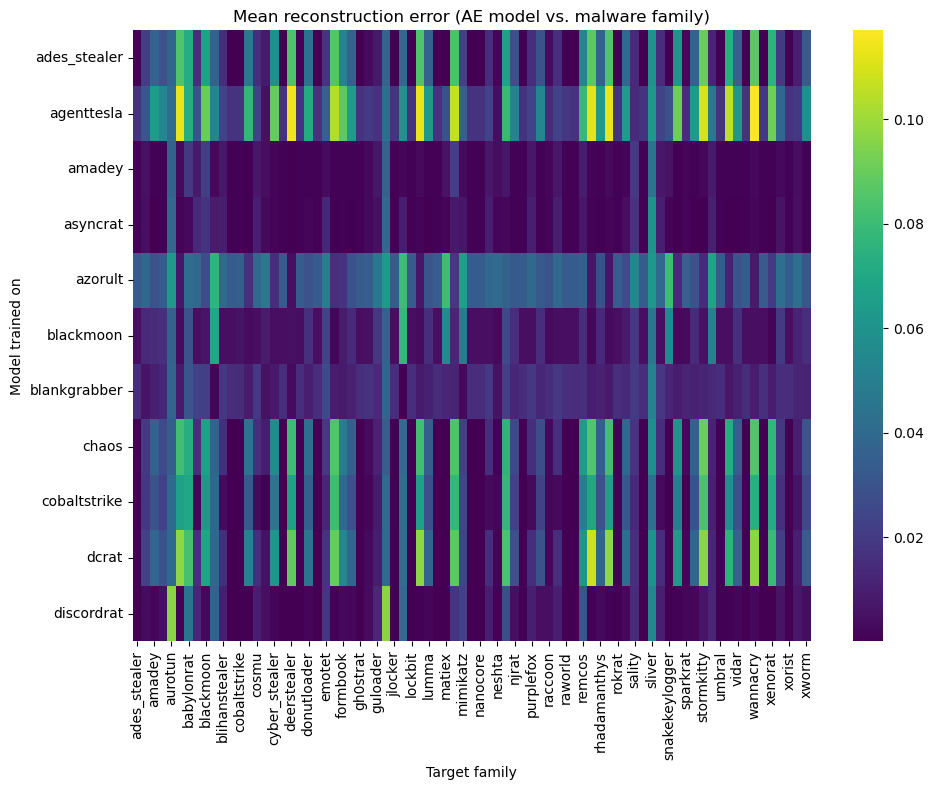

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_mean = df_eval.pivot(index="model_family", columns="target_family", values="mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_mean, annot=False, cmap="viridis")
plt.title("Mean reconstruction error (AE model vs. malware family)")
plt.xlabel("Target family")
plt.ylabel("Model trained on")
plt.tight_layout()
plt.show()

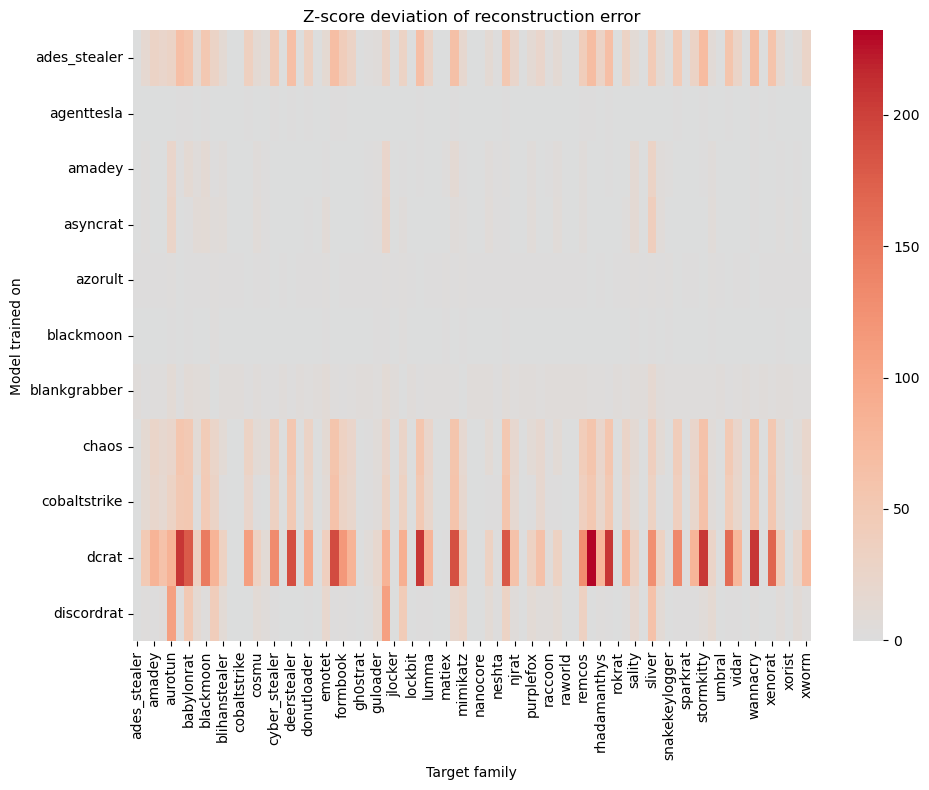

In [7]:
pivot_z = df_eval.pivot(index="model_family", columns="target_family", values="z_mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_z, annot=False, cmap="coolwarm", center=0)
plt.title("Z-score deviation of reconstruction error")
plt.xlabel("Target family")
plt.ylabel("Model trained on")
plt.tight_layout()
plt.show()